데이터 로딩 중...


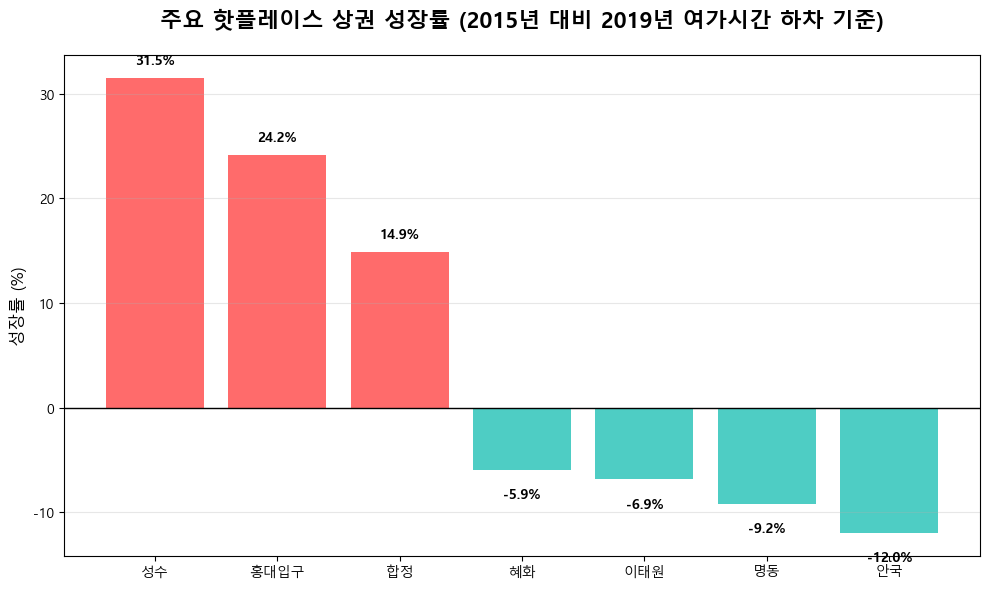

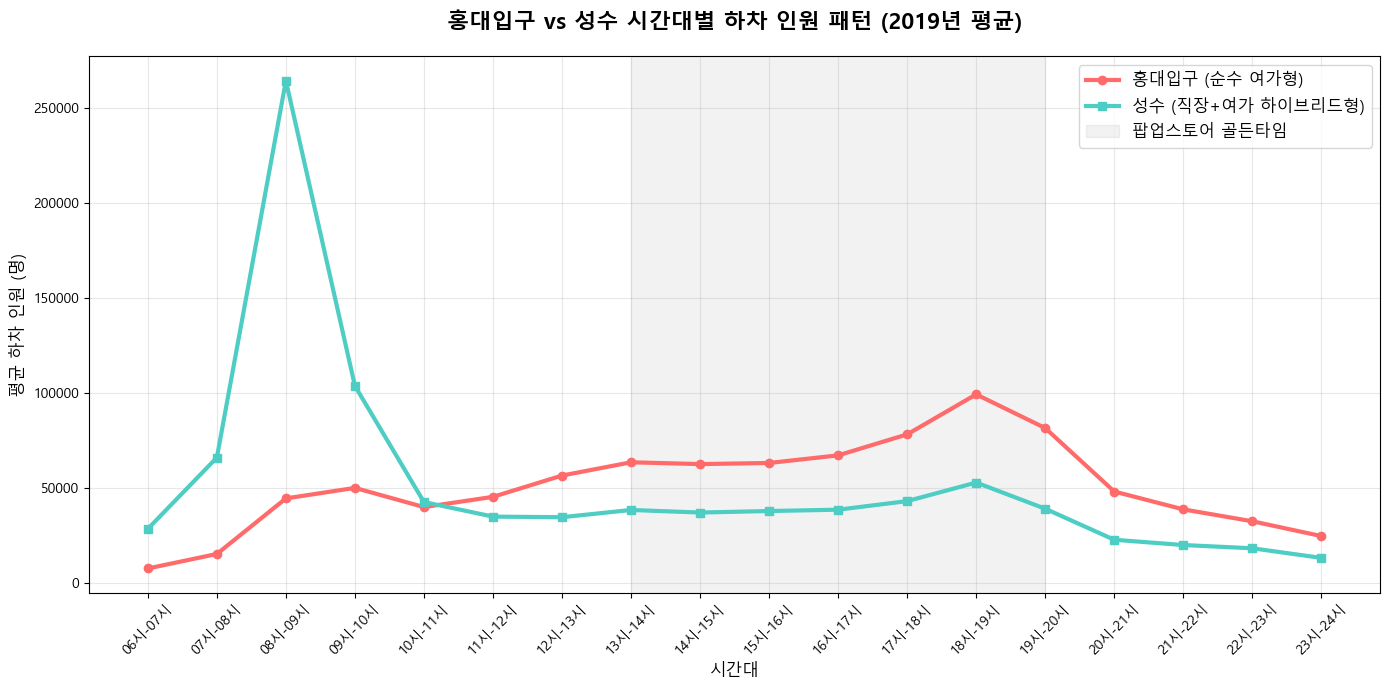

In [4]:
# 1. 라이브러리 및 폰트 세팅 (Jupyter Notebook 환경)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows는 'Malgun Gothic', Mac은 'AppleGothic')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_palette("Set2")

# 2. 데이터 로드 및 전처리
print("데이터 로딩 중...")
# 파일 인코딩 에러 방지를 위해 cp949 사용
file_path = r'C:\yeardreamschool6th\dataset\Seoul_subway_data_20210705.csv'
df = pd.read_csv(file_path, encoding='cp949')

# 타겟 상권 7곳 지정
target_stations = ['홍대입구', '명동', '혜화', '이태원', '합정', '안국', '성수']
df_target = df[df['지하철역'].isin(target_stations)].copy()

# 연도 파생변수 생성
df_target['Year'] = (df_target['사용월'] // 100).astype(int)

# 여가 시간대(13시~18시) 하차 인원 컬럼 추출 및 총합 계산
leisure_cols = ['13시-14시 하차인원', '14시-15시 하차인원', '15시-16시 하차인원', '16시-17시 하차인원', '17시-18시 하차인원']
df_target['여가_하차_총합'] = df_target[leisure_cols].sum(axis=1)

# ==========================================
# [차트 1] 상권별 여가시간 하차인원 성장률 (2015 vs 2019)
# ==========================================
yearly_trend = df_target.groupby(['Year', '지하철역'])['여가_하차_총합'].sum().reset_index()
pivot_trend = yearly_trend.pivot(index='Year', columns='지하철역', values='여가_하차_총합')

growth_data = []
for station in target_stations:
    val_15 = pivot_trend.loc[2015, station]
    val_19 = pivot_trend.loc[2019, station]
    growth = ((val_19 - val_15) / val_15) * 100
    growth_data.append({'지하철역': station, '성장률(%)': growth})

df_growth = pd.DataFrame(growth_data).sort_values(by='성장률(%)', ascending=False)

plt.figure(figsize=(10, 6))
# 성장률 양수/음수 색상 구분
colors = ['#FF6B6B' if x > 0 else '#4ECDC4' for x in df_growth['성장률(%)']]
bars = plt.bar(df_growth['지하철역'], df_growth['성장률(%)'], color=colors)

# 바 위에 수치 표시
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (1 if yval > 0 else -3), 
             f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.title('주요 핫플레이스 상권 성장률 (2015년 대비 2019년 여가시간 하차 기준)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('성장률 (%)', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# [차트 2] 홍대입구 vs 성수 시간대별 하차 인원 추이 (2019년 기준)
# ==========================================
# 2019년 데이터만 필터링
df_2019 = df_target[df_target['Year'] == 2019]

# 비교할 두 역 필터링
df_compare = df_2019[df_2019['지하철역'].isin(['홍대입구', '성수'])]

# 하차 인원 컬럼만 추출 (06시 ~ 23시)
alight_cols = [c for c in df.columns if '하차' in c][2:20] # 06시~24시 구간 적절히 슬라이싱
time_labels = [c.split(' ')[0] for c in alight_cols]

# 두 역의 시간대별 평균 계산
hourly_compare = df_compare.groupby('지하철역')[alight_cols].mean().T

plt.figure(figsize=(14, 7))
plt.plot(time_labels, hourly_compare['홍대입구'], marker='o', linewidth=3, label='홍대입구 (순수 여가형)', color='#FF6B6B')
plt.plot(time_labels, hourly_compare['성수'], marker='s', linewidth=3, label='성수 (직장+여가 하이브리드형)', color='#4ECDC4')

# 골든타임 강조 영역 (Shaded Region)
plt.axvspan('13시-14시', '19시-20시', color='gray', alpha=0.1, label='팝업스토어 골든타임')

plt.title('홍대입구 vs 성수 시간대별 하차 인원 패턴 (2019년 평균)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('시간대', fontsize=12)
plt.ylabel('평균 하차 인원 (명)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()